# 2. Searching PED

PED holds over 25,000 entries: a few hundred experimentally derived ensembles, plus large numbers of molecular dynamics ensembles and structure-based predictions (AlphaFlex, AF-CALVADOS, IDPForge and others). Finding the right ones is usually the first job.

`ped.search()` returns identifiers and `ped.search_entries()` returns full `PEDEntry` records. Both take the same criteria, which PED combines with AND, and both page through the results automatically. Nothing is downloaded here: searches only return metadata.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from soursop import ped

# Figure style: Arial throughout, text kept editable in Illustrator, no grid
# lines, and the xmgrace colour order (black, red, blue, green, purple)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.grid": False,
    "axes.prop_cycle": plt.cycler(color=["black", "red", "blue", "green", "purple"]),
})

# Downloaded ensembles are kept here and reused, so each is only fetched once
# (shared by all the notebooks in this folder)
CACHE = "ped_cache"

from collections import Counter

## Free text

The first positional argument is PED's free-text search across the whole entry: titles, protein names, methods, cross-references and so on.

In [2]:
print(ped.search("sic1"))

['PED00001', 'PED00014', 'PED00023', 'PED00159', 'PED00160', 'PED00161', 'PED00423', 'PED00424', 'PED00454', 'PED00455', 'PED00486', 'PED00487', 'PED08401', 'PED10849', 'PED12540', 'PED16555', 'PED17075', 'PED19400', 'PED19406', 'PED19412', 'PED20283']


Free text can be broad. `max_results` stops the search early, which matters for common words.

In [3]:
print(ped.search("SAXS", max_results=10))

['PED00001', 'PED00002', 'PED00021', 'PED00005', 'PED00007', 'PED00008', 'PED00010', 'PED00013', 'PED00014', 'PED00019']


## By protein

`protein_name` and `uniprot` target the constructs in the entry. UniProt accessions are the most reliable way to collect every entry for a protein.

In [4]:
print("tau:            ", ped.search(protein_name="tau")[:12], "...")
print("alpha-synuclein:", ped.search(uniprot="P37840"))

tau:             ['PED00017', 'PED00192', 'PED00263', 'PED00264', 'PED00265', 'PED00422', 'PED00443', 'PED00480', 'PED03086', 'PED03590', 'PED04633', 'PED05562'] ...


alpha-synuclein: ['PED00006', 'PED00024', 'PED00189', 'PED00232', 'PED00386', 'PED00425', 'PED00426', 'PED00477', 'PED00484', 'PED00543', 'PED00544', 'PED00545', 'PED02470', 'PED08390', 'PED10839', 'PED12536', 'PED16526', 'PED17034', 'PED17038', 'PED17043', 'PED17048', 'PED17052', 'PED19316', 'PED19320', 'PED19325', 'PED19326', 'PED19330', 'PED19334', 'PED20241']


## By method

`term` matches the IDPO ontology terms PED attaches to each entry: the experimental methods (NMR, SAXS, smFRET, ...) and ensemble-generation methods.

In [5]:
for method in ["NMR", "SAXS", "smFRET", "PRE"]:
    ids = ped.search(term=method)
    print(f"{method:7s} {len(ids):5d} entries, e.g. {ids[:4]}")

NMR       405 entries, e.g. ['PED00001', 'PED00009', 'PED00004', 'PED00012']


SAXS      121 entries, e.g. ['PED00001', 'PED00002', 'PED00021', 'PED00005']


smFRET     21 entries, e.g. ['PED00125', 'PED00126', 'PED00156', 'PED00157']


PRE        60 entries, e.g. ['PED00001', 'PED00023', 'PED00022', 'PED00006']


## By publication

`publication` takes a PubMed ID or DOI.

In [6]:
print(ped.search(publication="20399186"))

['PED00001', 'PED00014', 'PED00023']


## Combining criteria

Criteria combine with AND. For example, alpha-synuclein entries that used SAXS:

In [7]:
print(ped.search(uniprot="P37840", term="SAXS"))

['PED00543', 'PED00544', 'PED00545']


## Ensemble identifiers

With `ensembles=True`, `search()` returns one identifier per *ensemble*, ready to pass to `ped.load_ensemble()`.

In [8]:
print(ped.search("sic1", ensembles=True, max_results=4))

['PED00001e001', 'PED00001e002', 'PED00001e003', 'PED00014e001', 'PED00014e002', 'PED00014e003', 'PED00023e001', 'PED00023e002', 'PED00023e003', 'PED00159e001']


## Summarising results with `search_entries()`

`search_entries()` returns `PEDEntry` records, so you can filter and summarise without downloading anything. Here is every alpha-synuclein entry, with its ensembles, their sizes, and the methods used.

In [9]:
asyn = ped.search_entries(uniprot="P37840")

print(f"{'entry':10s} {'ensembles (conformers)':26s} {'title'}")
for e in asyn:
    ensembles = ", ".join(f"{s.ensemble_id} ({s.n_models})" for s in e.ensembles)
    print(f"{e.entry_id:10s} {ensembles:26s} {e.title[:60]}")

entry      ensembles (conformers)     title
PED00006   e001 (576)                 Structural ensemble of hybrid beta synuclein G25E (1-72); al
PED00024   e001 (576)                 Structural ensemble of alpha-synuclein
PED00189   e001 (34)                  NMR and EPR-based ensemble of the SLAS-micelle bound alpha-s
PED00232   e001 (8)                   The ensemble structure of alpha-synuclein monomer determined
PED00386   e001 (20)                  Structural ensemble of the complex of an N-terminally acetyl
PED00425   e002 (1000)                Alpha-synuclein ensemble generated with fractional secondary
PED00426   e001 (1000)                Alpha-synuclein ensemble generated with fractional secondary
PED00477   e003 (1000)                Structural ensemble of alpha-synuclein via the idpGAN machin
PED00484   e003 (100)                 Structural ensemble of hybrid beta synuclein G25E (1-72); al
PED00543   e001 (2998)                Structural ensemble of 𝛼-synuclein [C36m (reweigh

Entries from experiments carry ontology terms for their methods, while many of the large-scale predictions carry none. That makes it easy to split them, or to count which methods have been used for a protein.

13 entries with method annotations, 16 without


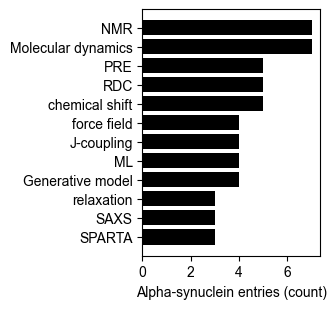

In [10]:
experimental = [e for e in asyn if e.ontology_terms]
predicted = [e for e in asyn if not e.ontology_terms]
print(f"{len(experimental)} entries with method annotations, {len(predicted)} without")

counts = Counter(term.strip() for e in experimental for term in e.ontology_terms)
top = counts.most_common(12)

fig, ax = plt.subplots(figsize=(3.4, 3.2))
ax.barh([t for t, n in top][::-1], [n for t, n in top][::-1], color="black")
ax.set_xlabel("Alpha-synuclein entries (count)")
plt.tight_layout()
plt.show()

## Two quirks of PED's search

* `author` matches PED's *data owner* (the depositor), not the paper's author list, so searching for an author usually finds nothing. Use free text instead: `ped.search("Forman-Kay")`.
* `cross_ref` currently returns a server error from PED (HTTP 500). A free-text search for the identifier works: `ped.search("DP00631")`.

Also note that a search with **no** criteria returns every entry in PED: over 25,000 records, which takes several minutes. Always narrow it down, or use `max_results`.

In [11]:
print("free text 'Forman-Kay':", ped.search("Forman-Kay", max_results=8))
print("free text 'DP00631':   ", ped.search("DP00631"))

free text 'Forman-Kay': ['PED00001', 'PED00014', 'PED00023', 'PED00022', 'PED00156', 'PED00157', 'PED00158', 'PED00159']


free text 'DP00631':    ['PED00001', 'PED00014', 'PED00023', 'PED00159', 'PED00160', 'PED00161', 'PED00454', 'PED00455', 'PED00486', 'PED00487', 'PED08401', 'PED10849', 'PED12540', 'PED16555', 'PED17075', 'PED19400', 'PED19406', 'PED19412', 'PED20283']
